# Suppressed activation steering

This notebook finds one prompt's vocabulary directions that rise in the middle layers and fall
before output. It then replaces that residual-stream component with the component from a second
prompt. Edit the configuration cell and read the dose grid at positive and negative strengths.

The extraction and intervention functions are the same ones used for Figure 2 in the
[README](../README.md). This is sample-specific: extraction first runs each complete prompt
without intervention.

In [1]:
import os
from pathlib import Path
import subprocess
import sys

ROOT = Path(os.environ.get("SUPPRESSED_ROOT", ".")).resolve()
sys.path.insert(0, str(ROOT))

import torch
from IPython.display import Image, display
from tabulate import tabulate
from transformers import AutoModelForCausalLM, AutoTokenizer

from scripts.demo import (
    generate,
    intervention_hooks,
    layer_hooks,
    metrics,
    one_token,
    run_forward,
    top_tokens,
    trajectory,
)
from suppressed_activation_subspace import suppressed_activation_subspace

# Edit this cell. `just notebook-smoke` overrides the same values with environment variables.
MODEL = os.environ.get("SUPPRESSED_MODEL", "Qwen/Qwen3.5-4B")
DEVICE = os.environ.get("SUPPRESSED_DEVICE", "cuda")
SOURCE_PROMPT = os.environ.get(
    "SUPPRESSED_SOURCE_PROMPT", "Fact: The number of legs on the animal that spins webs is "
)
TARGET_PROMPT = os.environ.get(
    "SUPPRESSED_TARGET_PROMPT",
    "Fact: The number of legs on the animal that barks and is called man's best friend is ",
)
SOURCE_OUTPUT = os.environ.get("SUPPRESSED_SOURCE_OUTPUT", "8")
TARGET_OUTPUT = os.environ.get("SUPPRESSED_TARGET_OUTPUT", "4")
EARLY_LAYER = int(os.environ.get("SUPPRESSED_EARLY_LAYER", 23))
PEAK_LAYER = int(os.environ.get("SUPPRESSED_PEAK_LAYER", 25))
OUTPUT_LAYER = int(os.environ.get("SUPPRESSED_OUTPUT_LAYER", 32))
INTERVENTION_START = int(os.environ.get("SUPPRESSED_INTERVENTION_START", 23))
INTERVENTION_END = int(os.environ.get("SUPPRESSED_INTERVENTION_END", 30))
RANK = int(os.environ.get("SUPPRESSED_RANK", 8))
MAX_NEW_TOKENS = int(os.environ.get("SUPPRESSED_TOKENS", 64))
DEMO_STRENGTH = float(os.environ.get("SUPPRESSED_DEMO_STRENGTH", 2))
STRENGTHS = tuple(
    float(value)
    for value in os.environ.get(
        "SUPPRESSED_STRENGTHS", "-0.5,-0.25,-0.125,0,0.125,0.25,0.5,1,2"
    ).split(",")
)
GIT_DESCRIBE = subprocess.run(
    ["git", "describe", "--always", "--dirty"],
    cwd=ROOT,
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()
{
    "git": GIT_DESCRIBE,
    "model": MODEL,
    "layers": (EARLY_LAYER, PEAK_LAYER, OUTPUT_LAYER),
    "intervention": (INTERVENTION_START, INTERVENTION_END),
    "rank": RANK,
    "readout strength": DEMO_STRENGTH,
    "strengths": STRENGTHS,
}

/workspace/2026/suppressed-activations/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'git': 'v0.1.1-24-g25f1194',
 'model': 'Qwen/Qwen3.5-4B',
 'layers': (23, 25, 32),
 'intervention': (23, 30),
 'rank': 8,
 'readout strength': 2.0,
 'strengths': (-0.5, -0.25, -0.125, 0.0, 0.125, 0.25, 0.5, 1.0, 2.0)}

## Load the model and extract both sample-specific subspaces

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)
dtype = torch.bfloat16 if DEVICE == "cuda" else torch.float32
model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=dtype).to(DEVICE).eval()
language_model = model.model
blocks = language_model.layers
final_norm = language_model.norm
unembedding = model.lm_head.weight
norm_gain = 1.0 + final_norm.weight

source_ids = tokenizer(SOURCE_PROMPT, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
target_ids = tokenizer(TARGET_PROMPT, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
source_residuals, clean_logits = trajectory(model, source_ids, final_norm)
target_residuals, target_clean_logits = trajectory(model, target_ids, final_norm)

source_basis, source_selected = suppressed_activation_subspace(
    source_residuals[:, -1][None],
    unembedding,
    norm_gain,
    early_layer=EARLY_LAYER,
    peak_layer=PEAK_LAYER,
    output_layer=OUTPUT_LAYER,
    rank=RANK,
    normalize_unembedding_rows=True,
)
target_basis, target_selected = suppressed_activation_subspace(
    target_residuals[:, -1][None],
    unembedding,
    norm_gain,
    early_layer=EARLY_LAYER,
    peak_layer=PEAK_LAYER,
    output_layer=OUTPUT_LAYER,
    rank=RANK,
    normalize_unembedding_rows=True,
)
source_basis, target_basis = source_basis[0], target_basis[0]
selected_words = {
    "source": [tokenizer.decode([token_id]) for token_id in source_selected[0]],
    "target": [tokenizer.decode([token_id]) for token_id in target_selected[0]],
}
selected_words

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 1575.03it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 426/426 [00:00<00:00, 7361.37it/s]

{'source': ['丝绸', '-web', 'Web', 'Disc', '的战', 'Spider', 'web', ' WEB'],
 'target': ['吠', ' собаки', '狗粮', 'dog', 'Dog', ' Dog', 'สุนัข', ' canine']}

`source_basis @ source_basis.T` and `target_basis @ target_basis.T` are projectors. The
replacement removes the source component, adds the target component at the same norm, and restores
the residual norm. It does not pair individual QR columns.

In [3]:
blocks_to_hook = range(INTERVENTION_START - 1, INTERVENTION_END)
source_output_id = one_token(tokenizer, SOURCE_OUTPUT)
target_output_id = one_token(tokenizer, TARGET_OUTPUT)


def hooks(strength: float):
    if strength == 0:
        return {}
    return intervention_hooks(
        source_basis,
        target_basis,
        target_residuals,
        operation="replace",
        strength=strength,
        blocks_to_hook=blocks_to_hook,
    )

## Read the suppressed tokens before and after replacement

In [4]:
clean_rows = []
for name, logits, expected_id in (
    ("source", clean_logits, source_output_id),
    ("target", target_clean_logits, target_output_id),
):
    logp = logits.log_softmax(-1)
    clean_rows.append({
        "prompt": name,
        "top next token": top_tokens(tokenizer, logits, 1)[0]["token"],
        "expected token": tokenizer.decode([expected_id]),
        "p(expected)": float(logp[expected_id].exp()),
    })
print(tabulate(clean_rows, headers="keys", tablefmt="rounded_outline", floatfmt="+.4f"))

with layer_hooks(blocks, hooks(DEMO_STRENGTH)):
    replaced_residuals, _ = trajectory(model, source_ids, final_norm)
_, replaced_selected = suppressed_activation_subspace(
    replaced_residuals[:, -1][None],
    unembedding,
    norm_gain,
    early_layer=EARLY_LAYER,
    peak_layer=PEAK_LAYER,
    output_layer=OUTPUT_LAYER,
    rank=RANK,
    normalize_unembedding_rows=True,
)
readout_rows = [
    {"trajectory": "source, before", "suppressed readout": ", ".join(selected_words["source"])},
    {"trajectory": "target, before", "suppressed readout": ", ".join(selected_words["target"])},
    {
        "trajectory": f"source, after C={DEMO_STRENGTH:g}",
        "suppressed readout": ", ".join(
            tokenizer.decode([token_id]) for token_id in replaced_selected[0]
        ),
    },
]
print(tabulate(readout_rows, headers="keys", tablefmt="rounded_outline"))

╭──────────┬──────────────────┬──────────────────┬───────────────╮
│ prompt   │   top next token │   expected token │   p(expected) │
├──────────┼──────────────────┼──────────────────┼───────────────┤
│ source   │                8 │                8 │       +0.8826 │
│ target   │                4 │                4 │       +0.9436 │
╰──────────┴──────────────────┴──────────────────┴───────────────╯


╭───────────────────┬─────────────────────────────────────────────────────────╮
│ trajectory        │ suppressed readout                                      │
├───────────────────┼─────────────────────────────────────────────────────────┤
│ source, before    │ 丝绸, -web, Web, Disc, 的战, Spider, web,  WEB          │
│ target, before    │ 吠,  собаки, 狗粮, dog, Dog,  Dog, สุนัข,  canine         │
│ source, after C=2 │ perros, hund, 狗粮,  krém,  implanta,  cbd,  Bite,  cão │
╰───────────────────┴─────────────────────────────────────────────────────────╯


## Sweep positive and negative strengths

Positive strength moves from the source component toward the target component. Negative strength
moves in the opposite direction. Dog and C=2 were selected after inspecting candidate prompts and
this dose sweep, so this is an exploratory demo rather than a held-out success rate. Excessive
intervention can repeat, change task format, or become malformed.

In [5]:
print(
    f"Positive C moves source → target at residual layers "
    f"L{INTERVENTION_START}–L{INTERVENTION_END}."
)
metric_rows = []
for strength in STRENGTHS:
    logits = clean_logits if strength == 0 else run_forward(model, source_ids, blocks, hooks(strength))
    row = metrics(tokenizer, logits, clean_logits, source_output_id, target_output_id)
    metric_rows.append(
        {
            "strength C": strength,
            "top token": row["top"][0]["token"],
            f"p({SOURCE_OUTPUT})": row["p_source"],
            f"p({TARGET_OUTPUT})": row["p_target"],
            "target/source log odds": row["log_odds_target_vs_source"],
            "KL from clean": row["kl_from_clean"],
        }
    )
print(tabulate(metric_rows, headers="keys", tablefmt="rounded_outline", floatfmt="+.4f"))

Positive C moves source → target at residual layers L23–L30.


╭──────────────┬─────────────┬─────────┬─────────┬──────────────────────────┬─────────────────╮
│   strength C │   top token │    p(8) │    p(4) │   target/source log odds │   KL from clean │
├──────────────┼─────────────┼─────────┼─────────┼──────────────────────────┼─────────────────┤
│      -0.5000 │           8 │ +0.8050 │ +0.0139 │                  -4.0625 │         +0.1077 │
│      -0.2500 │           8 │ +0.8828 │ +0.0267 │                  -3.5000 │         +0.0207 │
│      -0.1250 │           8 │ +0.8914 │ +0.0392 │                  -3.1250 │         +0.0045 │
│      +0.0000 │           8 │ +0.8826 │ +0.0564 │                  -2.7500 │         +0.0000 │
│      +0.1250 │           8 │ +0.8759 │ +0.0635 │                  -2.6250 │         +0.0006 │
│      +0.2500 │           8 │ +0.8674 │ +0.0712 │                  -2.5000 │         +0.0020 │
│      +0.5000 │           8 │ +0.8314 │ +0.0993 │                  -2.1250 │         +0.0135 │
│      +1.0000 │           8 │ +0.7151 │

In [6]:
generation_rows = []
for strength in STRENGTHS:
    result = generate(
        model,
        tokenizer,
        source_ids,
        blocks,
        hooks(strength),
        max_new_tokens=MAX_NEW_TOKENS,
    )
    generation_rows.append({"strength C": strength, "generation": result["text"]})
print(
    tabulate(
        generation_rows,
        headers="keys",
        tablefmt="grid",
        floatfmt="+.3f",
        maxcolwidths=[8, 110],
    )
)

+--------------+----------------------------------------------------------------------------------------------------------------+
|   strength C | generation                                                                                                     |
+==============+================================================================================================================+
|       -0.500 | 8丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸  |
|              | 丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝 |
|              | 绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸丝绸                                                                             |
+--------------+----------------------------------------------------------------------------------------------------------------+
|       -0.250 | 8.                                                                                                             |
|              | Hypothesis: The number of legs on the animal that spins webs is 6.   

## The measured replacement and controls

Figure 2 uses a prompt-only `C=2` replacement, source-component removal, and 256 random rank-8
replacements matched for residual norm and perturbation norm. The notebook grid above instead
keeps the hook active during generation so that excessive strengths are visible.

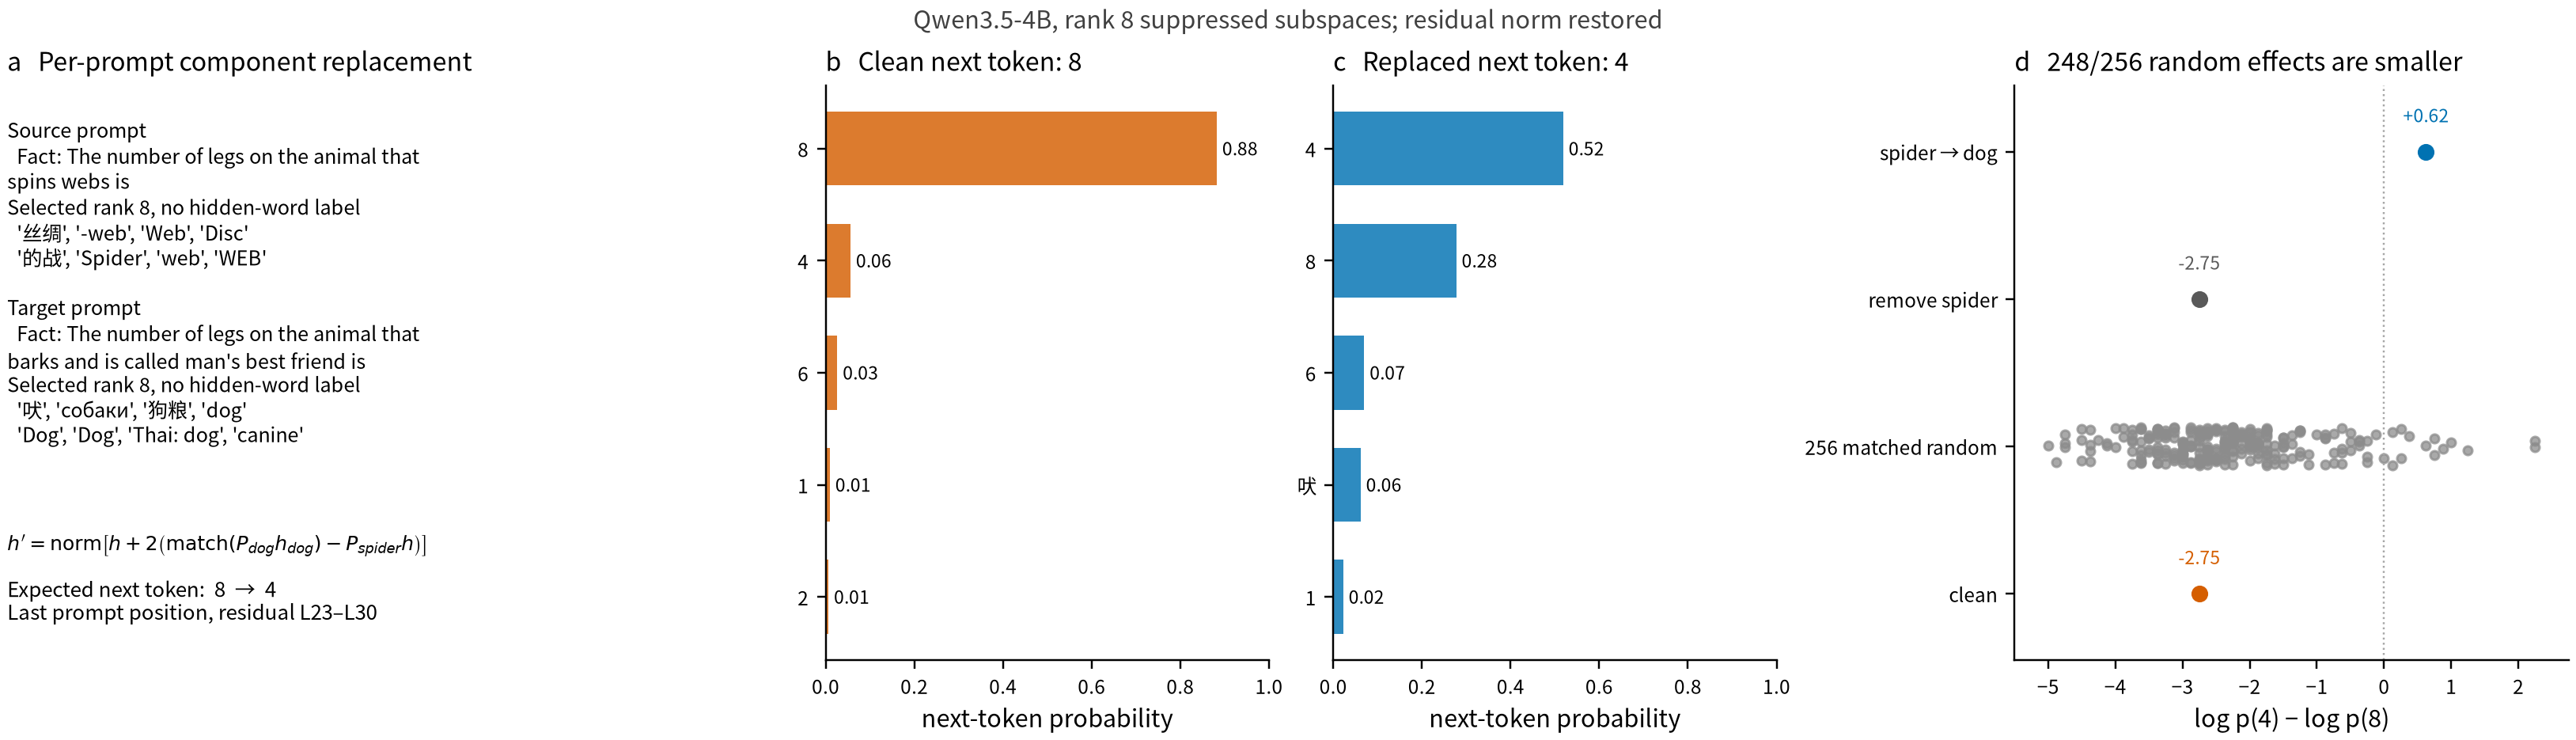

In [7]:
display(Image(filename=ROOT / "figs/causal_demo.png"))

<!-- Notebook drafted by PI/gpt-5.4 from Michael J. Clark's requested demo structure. -->